# TerraMind Teacher: Sensor Domain Gap (RQ1)

Scoped to the **untouched, pretrained TerraMind Tiny teacher only** -- no fine-tuning, no distillation, no `encoder_sim`. This notebook supports the "Sensor Gap in TerraMind Latent Space (RQ1)" section of the thesis Results and Discussion chapter: whether the domain gap between real $\Phi$-sat-2 and Sentinel-2B is visible in the teacher's own representation, and where in the encoder it concentrates.

The naive-fine-tuning ablation (previously `encoder_sim` in this notebook) is a *different*, superseded experiment -- it now belongs to the domain-adaptation-mechanism discussion in the Methodology chapter, not here. Keeping the two analyses in one notebook made past comparisons here (e.g. cosine similarity 0.80 vs 0.61) mix teacher-only and post-fine-tuning numbers under the same heading; splitting them removes that ambiguity.

## 1. Setup
Imports and the frozen, pretrained `terramind_v1_tiny` backbone. Bands are the 7-channel Blue..NIR mapping used throughout the thesis.

In [2]:
import json
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from terratorch import BACKBONE_REGISTRY

from dataset.constants import WC_CLASS_MAPPING

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

N_SAMPLES = 1000
SEED = 42
BATCH = 16
H5_PATH = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"
FIG_DIR = "/shared/home/elucas/scratch/masters-thesis/figures"

device: cuda


In [3]:
# Same sqrt -> clip -> per-domain z-score normalization as dataset_triplets_lulc.py
s2b_mean = np.array([49.0215, 48.4241, 49.2270, 51.1619, 55.4031, 57.3537, 56.7685], dtype=np.float32)
s2b_std = np.array([6.5464, 6.9918, 9.1444, 8.3999, 7.9740, 8.3373, 8.4429], dtype=np.float32)
s2b_clip = 100.0

real_mean = np.array([14.5305, 14.4030, 15.4191, 13.6231, 14.2143, 14.7041, 13.1745], dtype=np.float32)
real_std = np.array([10.6197, 9.4811, 9.0923, 10.5712, 10.4277, 10.3784, 9.7216], dtype=np.float32)
real_clip = 38.729

_s2b_mean_t = torch.tensor(s2b_mean, device=device).view(1, -1, 1, 1)
_s2b_std_t = torch.tensor(s2b_std, device=device).view(1, -1, 1, 1)
_real_mean_t = torch.tensor(real_mean, device=device).view(1, -1, 1, 1)
_real_std_t = torch.tensor(real_std, device=device).view(1, -1, 1, 1)


def norm_s2(img):
    """Sentinel-2B / simulated Phi-sat-2 (B,C,H,W) raw DN -> normalized (S2B stats, hard clip)."""
    x = torch.sqrt(img.clamp(min=0.0))
    x = x.clamp(max=float(s2b_clip))
    return (x - _s2b_mean_t) / _s2b_std_t


def norm_real(img, softness=6.0):
    """Real Phi-sat-2 (B,C,H,W) raw DN -> normalized (Phi-sat-2 stats, smooth clip)."""
    x = torch.sqrt(img.clamp(min=0.0))
    beta = 4.0 / max(softness, 1e-6)
    z = beta * (float(real_clip) - x)
    softplus = torch.logaddexp(torch.zeros_like(z), z) / beta
    x = float(real_clip) - softplus
    return (x - _real_mean_t) / _real_std_t

In [4]:
COMPARED_BANDS = {"S2L1C": {"B02": 0, "B03": 1, "B04": 2, "B05": 3, "B06": 4, "B07": 5, "B08": 6}}

encoder = BACKBONE_REGISTRY.build(
    "terramind_v1_base", pretrained=True, modalities=["S2L1C"], bands=COMPARED_BANDS
).to(device).eval()
print("TerraMind Base teacher loaded (pretrained, frozen -- no fine-tuning applied).")

TerraMind Base teacher loaded (pretrained, frozen -- no fine-tuning applied).


## 2. Extract per-layer embeddings for co-registered triplets
For `N_SAMPLES` randomly sampled, spatially/temporally co-registered patches, forward each of the three domains (Sentinel-2B, physics-simulated $\Phi$-sat-2, real $\Phi$-sat-2) through the frozen teacher, mean-pooling tokens at every layer. Dominant ESA WorldCover class per patch is also extracted from each domain's own mask, for the probe-transfer test below.

In [5]:
VALID_CLASSES = set(WC_CLASS_MAPPING.values())  # {0..10}


def dominant_class(mask_2d):
    vals, counts = np.unique(mask_2d, return_counts=True)
    for i in np.argsort(-counts):
        v = int(vals[i])
        if v in VALID_CLASSES:
            return v
    return -1


rng = np.random.default_rng(SEED)
t0 = time.time()

with h5py.File(H5_PATH, "r") as f:
    total = len(f["s2b/images"])
    idx = np.sort(rng.choice(total, size=N_SAMPLES, replace=False))

    layer_embs = {"s2b": [], "real": [], "sim": []}
    dom_labels = {"s2b": [], "real": []}

    for start in range(0, len(idx), BATCH):
        batch_idx = idx[start:start + BATCH]
        s2b_np = np.stack([f["s2b/images"][int(i)] for i in batch_idx]).astype(np.float32)
        real_np = np.stack([f["real/images"][int(i)][1:8] for i in batch_idx]).astype(np.float32)
        sim_np = np.stack([f["sim/images"][int(i)][1:8] for i in batch_idx]).astype(np.float32)
        s2b_mask = np.stack([f["s2b/masks"][int(i)] for i in batch_idx])
        real_mask = np.stack([f["real/masks"][int(i)] for i in batch_idx])

        dom_labels["s2b"].extend(dominant_class(m) for m in s2b_mask)
        dom_labels["real"].extend(dominant_class(m) for m in real_mask)

        s2b_t = norm_s2(torch.from_numpy(s2b_np).to(device))
        real_t = norm_real(torch.from_numpy(real_np).to(device))
        sim_t = norm_s2(torch.from_numpy(sim_np).to(device))

        with torch.no_grad():
            for name, tensor in [("s2b", s2b_t), ("real", real_t), ("sim", sim_t)]:
                layers = [layer.mean(dim=1).cpu().numpy() for layer in encoder(tensor)]
                layer_embs[name].append(np.stack(layers, axis=0))  # (n_layers, batch, dim)

for name in layer_embs:
    layer_embs[name] = np.concatenate(layer_embs[name], axis=1)  # (n_layers, N, dim)

n_layers = layer_embs["s2b"].shape[0]
dom_labels = {k: np.array(v) for k, v in dom_labels.items()}
print(f"Extracted {n_layers} layers x {N_SAMPLES} samples x 3 domains in {time.time() - t0:.1f}s")

Extracted 12 layers x 1000 samples x 3 domains in 210.5s


## 3. Paired cosine similarity (final layer)
Aggregate over all `N_SAMPLES` pairs, not a single anecdotal sample -- this is the number RQ1 actually needs.

S2B vs Real:  mean=0.9012  median=0.9171  std=0.0637
Sim vs Real:  mean=0.9032  median=0.9201  std=0.0639


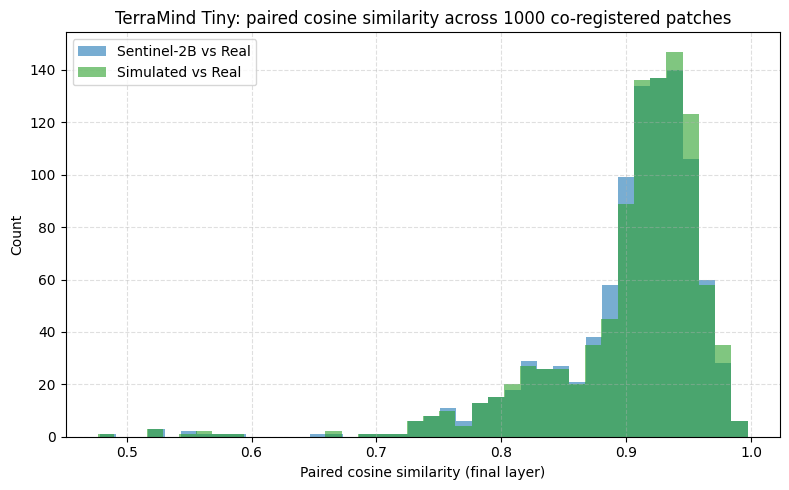

In [6]:
final = n_layers - 1
s2b_final = torch.from_numpy(layer_embs["s2b"][final])
real_final = torch.from_numpy(layer_embs["real"][final])
sim_final = torch.from_numpy(layer_embs["sim"][final])

cos_s2b_real = F.cosine_similarity(s2b_final, real_final, dim=1).numpy()
cos_sim_real = F.cosine_similarity(sim_final, real_final, dim=1).numpy()

print(f"S2B vs Real:  mean={cos_s2b_real.mean():.4f}  median={np.median(cos_s2b_real):.4f}  std={cos_s2b_real.std():.4f}")
print(f"Sim vs Real:  mean={cos_sim_real.mean():.4f}  median={np.median(cos_sim_real):.4f}  std={cos_sim_real.std():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(cos_s2b_real, bins=40, alpha=0.6, label="Sentinel-2B vs Real", color="#1f77b4")
plt.hist(cos_sim_real, bins=40, alpha=0.6, label="Simulated vs Real", color="#2ca02c")
plt.xlabel("Paired cosine similarity (final layer)")
plt.ylabel("Count")
plt.title(f"TerraMind Tiny: paired cosine similarity across {N_SAMPLES} co-registered patches")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_paired_cosine_dist.png", dpi=150)
plt.show()

## 4. Per-layer proxy $\mathcal{A}$-distance (PAD)
Domain separability (S2B vs Real) at every encoder layer, via 5-fold cross-validated linear SVM. PAD $\rightarrow 2$ means a probe separates the domains perfectly; PAD $\rightarrow 0$ means chance. This was a broken, unwired cell in the previous version of this notebook (`X`/`y` were never defined) -- it now actually runs, over all layers, on the teacher's own embeddings.

PAD per layer: ['1.918', '1.942', '1.956', '1.950', '1.932', '1.940', '1.944', '1.936', '1.938', '1.910', '1.898', '1.916']


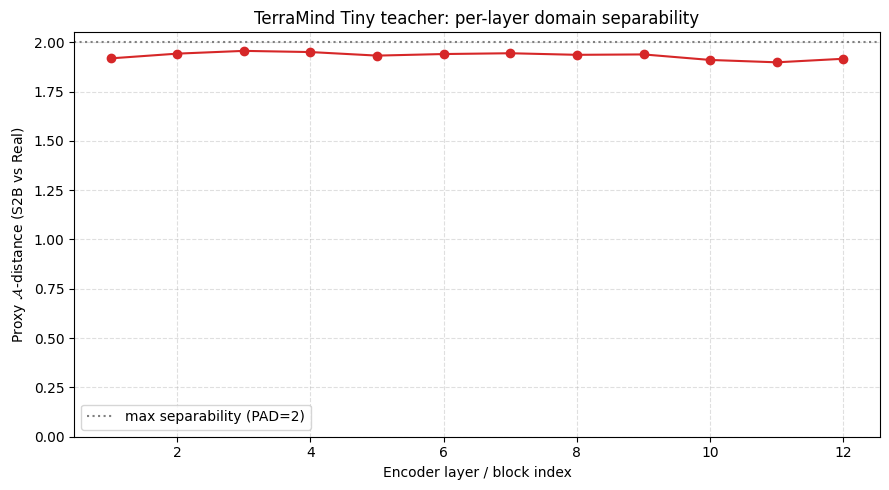

In [7]:
pad_per_layer = []
for layer in range(n_layers):
    X = np.concatenate([layer_embs["s2b"][layer], layer_embs["real"][layer]], axis=0)
    y = np.concatenate([np.zeros(N_SAMPLES), np.ones(N_SAMPLES)])
    clf = LinearSVC(max_iter=5000)
    scores = cross_val_score(clf, X, y, cv=5)
    error = 1.0 - scores.mean()
    pad_per_layer.append(2 * (1 - 2 * error))

print("PAD per layer:", [f"{p:.3f}" for p in pad_per_layer])

plt.figure(figsize=(9, 5))
plt.plot(range(1, n_layers + 1), pad_per_layer, marker="o", color="#d62728")
plt.axhline(2.0, color="gray", linestyle=":", label="max separability (PAD=2)")
plt.xlabel("Encoder layer / block index")
plt.ylabel("Proxy $\\mathcal{A}$-distance (S2B vs Real)")
plt.title("TerraMind Tiny teacher: per-layer domain separability")
plt.ylim(0, 2.05)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_pad_per_layer.png", dpi=150)
plt.show()

## 5. Per-layer paired cosine similarity curve
Where does similarity between paired views bottom out -- early layers (radiometric origin) or late layers (semantic origin)?

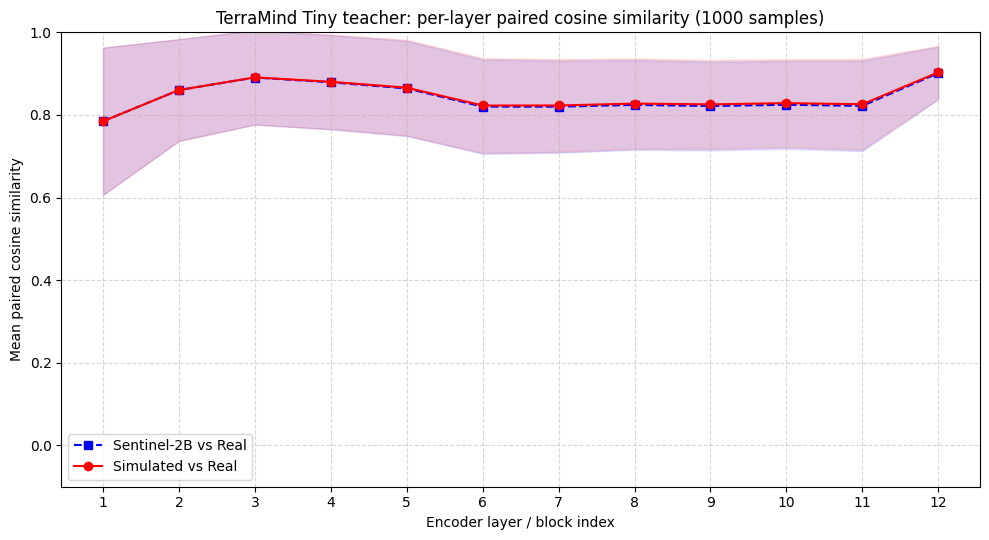

In [8]:
mean_s2r, std_s2r, mean_sr, std_sr = [], [], [], []
for layer in range(n_layers):
    c1 = F.cosine_similarity(torch.from_numpy(layer_embs["s2b"][layer]), torch.from_numpy(layer_embs["real"][layer]), dim=1).numpy()
    c2 = F.cosine_similarity(torch.from_numpy(layer_embs["sim"][layer]), torch.from_numpy(layer_embs["real"][layer]), dim=1).numpy()
    mean_s2r.append(c1.mean()); std_s2r.append(c1.std())
    mean_sr.append(c2.mean()); std_sr.append(c2.std())

mean_s2r, std_s2r, mean_sr, std_sr = map(np.array, (mean_s2r, std_s2r, mean_sr, std_sr))
layers_x = np.arange(1, n_layers + 1)

plt.figure(figsize=(10, 5.5))
plt.plot(layers_x, mean_s2r, marker="s", linestyle="--", color="b", label="Sentinel-2B vs Real")
plt.fill_between(layers_x, mean_s2r - std_s2r, mean_s2r + std_s2r, alpha=0.12, color="b")
plt.plot(layers_x, mean_sr, marker="o", linestyle="-", color="r", label="Simulated vs Real")
plt.fill_between(layers_x, mean_sr - std_sr, mean_sr + std_sr, alpha=0.12, color="r")
plt.title(f"TerraMind Tiny teacher: per-layer paired cosine similarity ({N_SAMPLES} samples)")
plt.xlabel("Encoder layer / block index")
plt.ylabel("Mean paired cosine similarity")
plt.xticks(layers_x)
plt.ylim(-0.1, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_cosine_per_layer.png", dpi=150)
plt.show()

## 6. Cross-domain linear-probe transfer
Fit a linear probe on Sentinel-2B final-layer embeddings against each patch's dominant ESA WorldCover class, then apply the *same* probe to the co-registered Real $\Phi$-sat-2 embeddings of the same patches. This is the actual downstream-task-relevant version of the domain-gap question, not just "can a classifier tell the domains apart."

valid labelled pairs: 989 / 1000
In-domain accuracy  (S2B -> S2B):  0.9327
Cross-domain accuracy (S2B -> Real): 0.0000
Retention: 0.0%


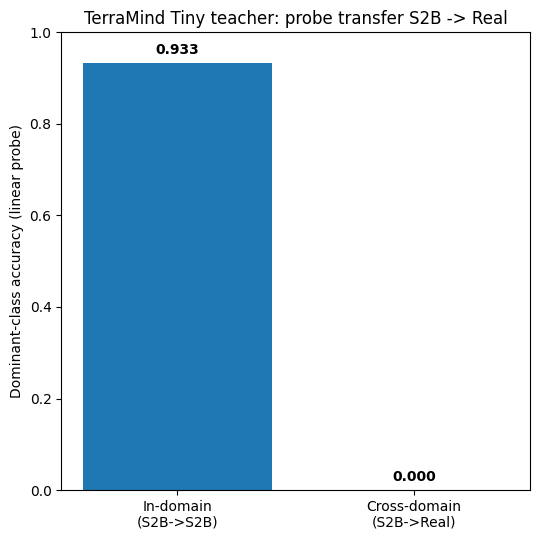

In [9]:
valid = (dom_labels["s2b"] >= 0) & (dom_labels["real"] >= 0)
print(f"valid labelled pairs: {valid.sum()} / {N_SAMPLES}")

Xs2b, ys2b = layer_embs["s2b"][final][valid], dom_labels["s2b"][valid]
Xreal, yreal = layer_embs["real"][final][valid], dom_labels["real"][valid]

n_valid = valid.sum()
order = rng.permutation(n_valid)
split = int(0.7 * n_valid)
train_idx, test_idx = order[:split], order[split:]

probe = LogisticRegression(max_iter=2000)
probe.fit(Xs2b[train_idx], ys2b[train_idx])
in_domain_acc = probe.score(Xs2b[test_idx], ys2b[test_idx])
cross_domain_acc = probe.score(Xreal[test_idx], yreal[test_idx])

print(f"In-domain accuracy  (S2B -> S2B):  {in_domain_acc:.4f}")
print(f"Cross-domain accuracy (S2B -> Real): {cross_domain_acc:.4f}")
print(f"Retention: {100 * cross_domain_acc / in_domain_acc:.1f}%")

plt.figure(figsize=(5.5, 5.5))
plt.bar(["In-domain\n(S2B->S2B)", "Cross-domain\n(S2B->Real)"], [in_domain_acc, cross_domain_acc], color=["#1f77b4", "#d62728"])
plt.ylabel("Dominant-class accuracy (linear probe)")
plt.title("TerraMind Tiny teacher: probe transfer S2B -> Real")
plt.ylim(0, 1.0)
for i, v in enumerate([in_domain_acc, cross_domain_acc]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_probe_transfer.png", dpi=150)
plt.show()

## 7. t-SNE and UMAP of final-layer embeddings
Teacher only, three domains.

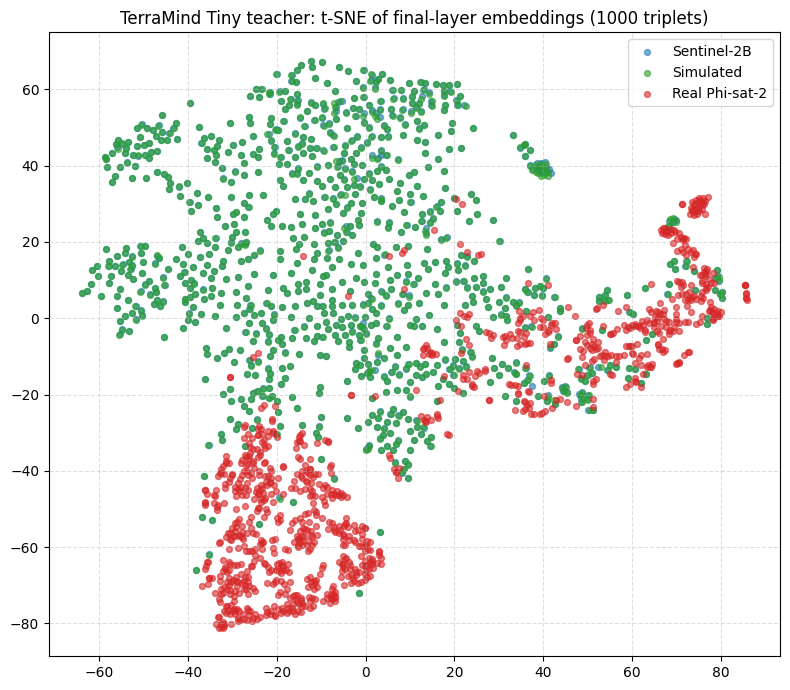

In [10]:
X_final = np.concatenate([layer_embs["s2b"][final], layer_embs["sim"][final], layer_embs["real"][final]], axis=0)
labels_3dom = (["Sentinel-2B"] * N_SAMPLES) + (["Simulated"] * N_SAMPLES) + (["Real Phi-sat-2"] * N_SAMPLES)
colors3 = {"Sentinel-2B": "#1f77b4", "Simulated": "#2ca02c", "Real Phi-sat-2": "#d62728"}

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_final)

plt.figure(figsize=(8, 7))
for dom in colors3:
    mask = np.array([l == dom for l in labels_3dom])
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=18, alpha=0.6, color=colors3[dom], label=dom)
plt.title(f"TerraMind Tiny teacher: t-SNE of final-layer embeddings ({N_SAMPLES} triplets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_tsne_teacher.png", dpi=150)
plt.show()

/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


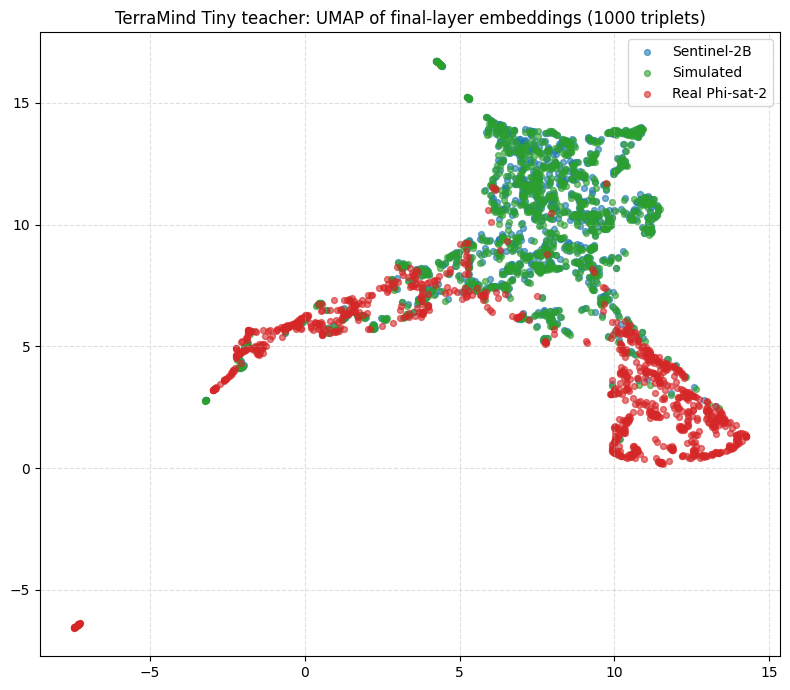

In [11]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_final)

plt.figure(figsize=(8, 7))
for dom in colors3:
    mask = np.array([l == dom for l in labels_3dom])
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], s=18, alpha=0.6, color=colors3[dom], label=dom)
plt.title(f"TerraMind Tiny teacher: UMAP of final-layer embeddings ({N_SAMPLES} triplets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rq1_umap_teacher.png", dpi=150)
plt.show()